# Canadian Laws — EDA

Dataset: `a2aj/canadian-laws` (~10.9k laws & regulations, 315 MB). One row per law; paired `_en`/`_fr` columns where the missing language is empty. `unofficial_text_en/fr` is markdown-formatted full text; `unofficial_sections_en/fr` is the same content pre-segmented as JSON; `num_sections_en/fr` counts sections.

In [171]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import re

In [172]:
from datasets import load_dataset
ds = load_dataset("a2aj/canadian-laws")

In [173]:
train = ds["train"]
print(train)

Dataset({
    features: ['citation_en', 'citation2_en', 'dataset', 'name_en', 'document_date_en', 'source_url_en', 'scraped_timestamp_en', 'unofficial_text_en', 'unofficial_sections_en', 'num_sections_en', 'citation_fr', 'citation2_fr', 'name_fr', 'document_date_fr', 'source_url_fr', 'scraped_timestamp_fr', 'unofficial_text_fr', 'unofficial_sections_fr', 'num_sections_fr', 'upstream_license'],
    num_rows: 22785
})


In [174]:
print(f"{'Column':<30} {'Non-null':>12} | {'Null':>12} | {'Total':>12} | {'Coverage':>9}")
print("-" * 85)

for col in train.features:
    # missing values in this dataset can be None OR empty string "" — count both as null
    nonnull = sum(x is not None and x != "" for x in train[col])
    null = len(train) - nonnull

    print(
        f"{col:<30} "
        f"{nonnull:>12,} | "
        f"{null:>12,} | "
        f"{len(train):>12,} | "
        f"{nonnull / len(train) * 100:>8.2f}%"
    )

Column                             Non-null |         Null |        Total |  Coverage
-------------------------------------------------------------------------------------
citation_en                          22,775 |           10 |       22,785 |    99.96%
citation2_en                            962 |       21,823 |       22,785 |     4.22%
dataset                              22,785 |            0 |       22,785 |   100.00%
name_en                              22,785 |            0 |       22,785 |   100.00%
document_date_en                     22,745 |           40 |       22,785 |    99.82%
source_url_en                        22,785 |            0 |       22,785 |   100.00%
scraped_timestamp_en                 22,785 |            0 |       22,785 |   100.00%
unofficial_text_en                   22,785 |            0 |       22,785 |   100.00%
unofficial_sections_en               22,777 |            8 |       22,785 |    99.96%
num_sections_en                      22,785 |         

In [175]:
# drop the heavy text/sections columns before pandas (num_sections_en/fr are small ints — keep those)
drop = ["unofficial_text_en", "unofficial_text_fr",
        "unofficial_sections_en", "unofficial_sections_fr"]
df = train.remove_columns(drop).to_pandas() # converts metadata to pandas

# IMPORTANT: this dataset marks missing values as empty strings "" OR NaN.
# .notna()/.isna() only catch NaN, so normalize "" -> NA first.
df = df.replace("", pd.NA)

print(df.columns.tolist())   # confirm the exact column names
print("Number of columns = ", len(df.columns.tolist()))
df.head()

['citation_en', 'citation2_en', 'dataset', 'name_en', 'document_date_en', 'source_url_en', 'scraped_timestamp_en', 'num_sections_en', 'citation_fr', 'citation2_fr', 'name_fr', 'document_date_fr', 'source_url_fr', 'scraped_timestamp_fr', 'num_sections_fr', 'upstream_license']
Number of columns =  16


,citation_en,citation2_en,dataset,name_en,document_date_en,source_url_en,scraped_timestamp_en,num_sections_en,citation_fr,citation2_fr,name_fr,document_date_fr,source_url_fr,scraped_timestamp_fr,num_sections_fr,upstream_license
0,"RSA 2000, c A-1",NaN,LEGISLATION-AB,ABC Benefits Corporation Act,2006-01-17 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-19 12:23:23.450000+00:00,18,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
1,"SA 2024, c A-1.4",NaN,LEGISLATION-AB,Access to Information Act,2025-12-18 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-19 12:23:33.929000+00:00,103,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
2,"RSA 2000, c A-3",NaN,LEGISLATION-AB,Administrative Procedures and Jurisdiction Act,2023-04-01 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-19 12:24:22.272000+00:00,16,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
3,"RSA 2000, c A-4",NaN,LEGISLATION-AB,Adult Adoption Act,2022-11-16 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-19 12:24:36.274000+00:00,13,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
4,"SA 2008, c A-4.2",NaN,LEGISLATION-AB,Adult Guardianship and Trusteeship Act,2026-04-01 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-19 12:24:52.093000+00:00,163,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...


## Basic counts & language coverage
Missing values can be `""` **or** `NaN` in this dataset, so we normalized empty strings to `NA` above — otherwise `.notna()` silently miscounts.

In [176]:
# number of english and french laws (based on which citation is present)
has_en = df["citation_en"].notna()   # True where an English citation exists
has_fr = df["citation_fr"].notna()   # True where a French citation exists

print(f"Total laws:       {len(df):,}")
print(f"Has English:      {has_en.sum():,}")
print(f"Has French:       {has_fr.sum():,}")
print(f"English only:     {(has_en & ~has_fr).sum():,}")
print(f"French only:      {(~has_en & has_fr).sum():,}")
print(f"Both languages:   {(has_en & has_fr).sum():,}")
print(f"Neither (odd!):   {(~has_en & ~has_fr).sum():,}")

# unique citations & duplicates (fall back to French citation when English missing)
citation = df["citation_en"].fillna(df["citation_fr"])
print(f"\nUnique citations:    {citation.nunique():,}")
print(f"Duplicate citations: {citation.dropna().duplicated().sum():,}")

# laws per subset, and bilingual coverage per subset
# (federal laws are legally bilingual -> expect ~100% 'Both'; BC/ON mostly English-only)
print("\nLaws per subset:")
print(df["dataset"].value_counts())
print("\nBilingual coverage by subset:")
print(pd.crosstab(df["dataset"], (has_en & has_fr).rename("both_languages")))

Total laws:       22,785
Has English:      22,775
Has French:       13,371
English only:     9,404
French only:      0
Both languages:   13,371
Neither (odd!):   10

Unique citations:    22,730
Duplicate citations: 45

Laws per subset:
dataset
REGULATIONS-FED    4868
REGULATIONS-ON     2206
REGULATIONS-NL     1663
REGULATIONS-NS     1504
REGULATIONS-BC     1466
REGULATIONS-YT     1355
REGULATIONS-MB     1093
LEGISLATION-FED     962
REGULATIONS-AB      909
LEGISLATION-ON      856
REGULATIONS-NB      675
REGULATIONS-SK      666
LEGISLATION-NS      625
LEGISLATION-BC      574
REGULATIONS-NT      561
LEGISLATION-MB      515
LEGISLATION-SK      505
LEGISLATION-AB      442
LEGISLATION-NB      421
LEGISLATION-NL      402
LEGISLATION-YT      278
LEGISLATION-NT      239
Name: count, dtype: int64

Bilingual coverage by subset:
both_languages   False  True 
dataset                      
LEGISLATION-AB     441      1
LEGISLATION-BC     574      0
LEGISLATION-FED      0    962
LEGISLATION-MB       

In [177]:
# distribution of number of characters
texts = train["unofficial_text_en"]   # list of 10,894 strings/None (fine at ~150 MB for this dataset)

# use df.index -> position in `texts`, so this keeps working after we drop rows from df
df["n_chars_en"] = [len(texts[i]) if texts[i] else 0 for i in df.index]

## Inspect the shortest documents (before cleaning)
Look before you delete. The short tail is where placeholder documents live — BC's `[Not included.]` spent amending acts, `[Repealed ...]` stubs, and possibly other sentinels. Survey them first, then decide the filter.

In [189]:
# raw output of the shortest documents, sorted by length ascending
short = df[df["n_chars_en"] > 0].sort_values("n_chars_en")

for i in short.index[:50]:                     # 15 shortest — raise as needed
    t = texts[int(i)]
    print(f"{'='*80}")
    print(f"row {int(i)} | {df.loc[i,'dataset']} | {df.loc[i,'name_en']} | {len(t)} chars")
    print(f"{'='*80}")
    print(repr(t))                              # raw string: \n visible, nothing stripped
    print()

row 3348 | LEGISLATION-NS | Arbor Day Act | 341 chars
'# Arbor Day Act\n\nRSNS 1989, c 20\n\nArbor Day Act\nAn Act to Provide for\nthe Designation of Arbor Day\n\n### Short title\n\n1 This Act may be cited as the *Arbor Day Act*.\n\n### Designation of Arbor Day\n\n2 The Governor in Council may designate one day each year to be kept and observed throughout the Province under the name of Arbor Day.\n__________'

row 18845 | REGULATIONS-ON | IESO Cost Recovery re Smart Metering initiative | 342 chars
'# IESO Cost Recovery re Smart Metering initiative\n\nO. Reg. 453/06\n\n### IESO cost recovery re smart metering\n\n1 Subject to a Board order, for the purposes of subsection 78 (3.0.3) of the Act, the IESO may recover the costs it incurs because of its role and responsibilities, as set out in its objects, related to the smart metering initiative.'

row 15386 | REGULATIONS-NL | Town of New-Wes-Valley Name Change Order | 342 chars
'# Town of New-Wes-Valley Name Change Order\n\nNLR 55/96\n\n*Ma

In [179]:
# what sentinel phrases appear in the short docs? (helps choose filter terms)
from collections import Counter
sentinels = Counter()
for i in short.index:
    t = (texts[int(i)] or "").lower()
    for phrase in ["not included", "[repealed", "repealed", "spent", "not in force", "[omitted"]:
        if phrase in t:
            sentinels[phrase] += 1
print(sentinels)


Counter({'repealed': 9095, '[repealed': 3118, 'spent': 815, 'not included': 748, 'not in force': 276, '[omitted': 1})


## Data cleaning: placeholder "stub" documents
Based on the inspection above, we remove documents that are just a title + a sentinel (`[Not included.]`, `[Repealed ...]`, ...). These are real laws legally, but their text isn't in the dataset, so they'd distort every length distribution.

**Note:** after dropping rows, `df`'s index keeps its original labels (with gaps). Do **not** `reset_index(drop=True)` — the labels are our link back to `train[i]` for fetching text.

In [180]:
# flag placeholder docs: short texts whose body is a sentinel like "[Not included.]" or "[Repealed ...]"
# (adjust the phrase list / length threshold based on what the inspection above showed)
SENTINELS = ["[not included", "[repealed"]

df["is_stub"] = [
    bool(texts[int(i)])
    and len(texts[int(i)]) < 500
    and any(s in texts[int(i)].lower() for s in SENTINELS)
    for i in df.index
]

removed = df[df["is_stub"]].copy()

print("Stub documents found:", df["is_stub"].sum())
print(df.loc[df["is_stub"], "dataset"].value_counts())
df.loc[df["is_stub"], ["dataset", "citation_en", "name_en", "n_chars_en"]].head(10)

Stub documents found: 598
dataset
REGULATIONS-FED    573
LEGISLATION-FED     19
LEGISLATION-BC       5
REGULATIONS-MB       1
Name: count, dtype: int64


,dataset,citation_en,name_en,n_chars_en
481,LEGISLATION-BC,"SBC 1996, c 9","Budget Measures Implementation Act, 1996",74
482,LEGISLATION-BC,"SBC 2000, c 22","Budget Measures Implementation Act, 2000",75
500,LEGISLATION-BC,"SBC 2018, c 17","Civil Resolution Tribunal Amendment Act, 2018",80
561,LEGISLATION-BC,"SBC 2008, c 44",Economic Incentive and Stabilization Statutes ...,100
590,LEGISLATION-BC,"SBC 2008, c 61","Expropriation Amendment Act, 2004",68
1103,LEGISLATION-FED,"RSC 1985, c 20 (4th Supp)",Canada Agricultural Products Act,391
1129,LEGISLATION-FED,"SC 2017, c 8",Canada–Ukraine Free Trade Agreement Implementa...,204
1152,LEGISLATION-FED,"SC 2012, c 19, s 52","Canadian Environmental Assessment Act, 2012",261
1236,LEGISLATION-FED,"SC 2024, c 17, s 198",Consumer-Driven Banking Act,170
1317,LEGISLATION-FED,"SC 2024, c 15, s 96",Digital Services Tax Act,151


In [181]:
# remove the stubs (keep original index labels — no reset_index!)
print("Before:", len(df))
df = df[~df["is_stub"]]
print("After: ", len(df))
df = df.sort_values("n_chars_en")
df = df[255:22187]
print("After slicing first 255: ", len(df))

# re-check: what's the short tail like now? should be real (just brief) laws
leftover = df[df["n_chars_en"].between(1, 255)]
print(leftover[["dataset", "name_en", "n_chars_en"]].sort_values("n_chars_en").head(10))

for i in leftover.sort_values("n_chars_en").index[:120]:                     # 15 shortest — raise as needed
    t = texts[int(i)]
    print(f"{'='*80}")
    print(f"row {int(i)} | {df.loc[i,'dataset']} | {df.loc[i,'name_en']} | {len(t)} chars")
    print(f"{'='*80}")
    print(repr(t))                              # raw string: \n visible, nothing stripped
    print()

removed[["dataset", "name_en", "n_chars_en"]].sort_values("n_chars_en", ascending=False).head(10)
for i in removed.sample(3, random_state=42).index:
    print(texts[int(i)][:800], "\n" + "-"*80)

Before: 22785
After:  22187
After slicing first 255:  21932
Empty DataFrame
Columns: [dataset, name_en, n_chars_en]
Index: []
# Order Designating the Minister of Public Works and Government Services as the Minister for the purposes of the Act

*SI/2016-19*

*Registration 2016-05-04*

*Enabling authority: PUBLIC SERVICE LABOUR RELATIONS ACT*

[Repealed, SI/2018-89]

[Repealed, SI/2018-89] 
--------------------------------------------------------------------------------
# Children’s Jewellery Regulations

*SOR/2005-132*

*Registration 2005-05-10*

*Enabling authority: HAZARDOUS PRODUCTS ACT*

[Repealed, SOR/2008-90, s. 1]

## Interpretation

**1** [Repealed, SOR/2008-90, s. 1]

## Authorization

**2** [Repealed, SOR/2008-90, s. 1]

## Coming into Force

**3** [Repealed, SOR/2008-90, s. 1]

[Repealed, SOR/2008-90, s. 1] 
--------------------------------------------------------------------------------
# Federal Authorities Regulations

*SOR/96-280*

*Registration 1996-05-28*

*Enabling aut

In [182]:
# optional audit: repealed sections INSIDE living laws (kept — tiny fraction of each document's text)
df["n_repealed_secs"] = [len(re.findall(r"\[Repealed", texts[i] or "")) for i in df.index]
print("Laws containing repealed sections:", (df["n_repealed_secs"] > 0).sum())
print("Total repealed-section markers:  ", df["n_repealed_secs"].sum())

Laws containing repealed sections: 2300
Total repealed-section markers:   33056


## Length distributions (after cleaning)

Number of missing-text rows =  0


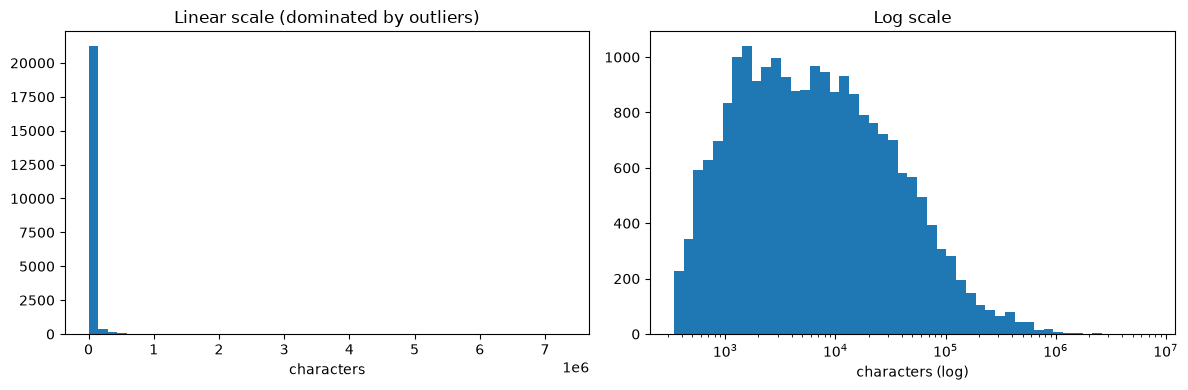

In [183]:
#plot distribution of characters
print("Number of missing-text rows = ", (df["n_chars_en"] == 0).sum())
lens = df.loc[df["n_chars_en"] > 0, "n_chars_en"]   # exclude missing-text rows

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# linear scale — see the skew
axes[0].hist(lens, bins=50)
axes[0].set_title("Linear scale (dominated by outliers)")
axes[0].set_xlabel("characters")

# log scale — see the actual shape
log_bins = np.logspace(np.log10(lens.min()), np.log10(lens.max()), 50)
axes[1].hist(lens, bins=log_bins)
axes[1].set_xscale("log")
axes[1].set_title("Log scale")
axes[1].set_xlabel("characters (log)")

plt.tight_layout()
plt.show()

In [184]:
print(leftover[["citation_en","dataset","num_sections_en"]].head())
print(df["n_chars_en"].describe())
print(df[["citation_en","dataset","num_sections_en"]].iloc[0])
print(df[["citation_en","dataset","num_sections_en"]].iloc[int(22187 * 0.5)])
print(df[["citation_en","dataset","num_sections_en"]].iloc[21931])
                    # 15 shortest — raise as needed
t = texts[int(df.index[0])]
print(f"{'='*80}")
print(f"row {0} | {df.loc[0,'dataset']} | {df.loc[0,'name_en']} | {len(t)} chars")
print(f"{'='*80}")
print(repr(t))                              # raw string: \n visible, nothing stripped
print()


Empty DataFrame
Columns: [citation_en, dataset, num_sections_en]
Index: []
count    2.193200e+04
mean     2.577444e+04
std      8.936353e+04
min      3.410000e+02
25%      1.780750e+03
50%      5.933000e+03
75%      2.071450e+04
max      7.314458e+06
Name: n_chars_en, dtype: float64
citation_en        RSNS 1989, c 20
dataset             LEGISLATION-NS
num_sections_en                  2
Name: 3348, dtype: object
citation_en        RSC 1985, c S-21
dataset             LEGISLATION-FED
num_sections_en                  15
Name: 1855, dtype: object
citation_en        RSC 1985, c 1 (5th Supp)
dataset                     LEGISLATION-FED
num_sections_en                         767
Name: 1515, dtype: object
row 0 | LEGISLATION-AB | ABC Benefits Corporation Act | 341 chars
'# Arbor Day Act\n\nRSNS 1989, c 20\n\nArbor Day Act\nAn Act to Provide for\nthe Designation of Arbor Day\n\n### Short title\n\n1 This Act may be cited as the *Arbor Day Act*.\n\n### Designation of Arbor Day\n\n2 The Governor i

In [185]:
t = texts[int(df.index[int(22187 * 0.5)])]
print(f"{'='*80}")
print(f"row {int(22187 * 0.5)} | {df.loc[int(22187 * 0.5),'dataset']} | {df.loc[int(22187 * 0.5),'name_en']} | {len(t)} chars")
print(f"{'='*80}")
print(repr(t))                              # raw string: \n visible, nothing stripped
print()

row 11093 | REGULATIONS-FED | Ferry-Boats Remission Order, 2016 | 6099 chars
'# Publication of Statutes Act\n\n*An Act respecting the publication of Statutes*\n\n*RSC 1985, c S-21*\n\n## Short Title\n\n**Short title**\n\n**1** This Act may be cited as the Publication of Statutes Act.\n\n## Interpretation\n\n**Definition of Minister**\n\n**2** In this Act, **Minister** means the Minister of Public Works and Government Services.\n\n## The Clerk of the Parliaments\n\n**Clerk of the Parliaments to have custody of original Acts**\n\n**3** All the original Acts passed by the Legislatures of the former Provinces of Upper Canada and Lower Canada, or of the former Province of Canada, transferred to and deposited of record in the office of the Clerk of the Senate, and all original Acts of the Parliament of Canada assented to by the Governor General, shall be and continue to remain of record in the custody of the Clerk of the Senate of Canada, who shall be known and designated as the Clerk of the

In [186]:

t = texts[int(df.index[21900])]
print(f"{'='*80}")
print(f"row {21930} | {df.loc[21930,'dataset']} | {df.loc[21930,'name_en']} | {len(t)} chars")
print(f"{'='*80}")
print(repr(t))                              # raw string: \n visible, nothing stripped
print()

row 21930 | REGULATIONS-YT | Transfer of Lands (Watson Lake) | 799015 chars
'# PROCEEDINGS COMMENCED BY CERTIFICATE OF OFFENCE\n\nR.R.O. 1990, Reg. 950\n\nNote: This regulation is not fully bilingual as many of its Schedules are in English only.\n1.-4.3.1 Revoked: O. Reg. 106/11, s. 1.\n4.4 The clerk of the court or an assistant clerk, if so authorized by the clerk, is a designated person for the purposes of subsections 69 (3) and (5) of the Act.\n4.5 Revoked: O. Reg. 68/12, s. 1.\n5 (1) The words or expressions set out in Column 2 of a Schedule may be used in a certificate of offence, offence notice or summons to designate the offence described in the provision set out opposite in Column 3 of the Schedule under the Act or regulation set out in the heading to the Schedule.\n(2) For the purposes of subsection (1), either the English version or the French version, if any, of a Schedule may be used.\n6 Revoked: O. Reg. 192/24, s. 1.\n7 Revoked: O. Reg. 682/92, s. 1.\n\n### Forms 1-9 Revok

In [187]:
df["jurisdiction"] = df["dataset"].str.split("-").str[-1]
grouped = df.groupby("jurisdiction")
print(df.head())

           citation_en citation2_en         dataset  \
3348   RSNS 1989, c 20          NaN  LEGISLATION-NS   
18845     O Reg 453/06          NaN  REGULATIONS-ON   
15386        NLR 55/96          NaN  REGULATIONS-NL   
7391   BC Reg 302/2006          NaN  REGULATIONS-BC   
15594      CNLR 397/96          NaN  REGULATIONS-NL   

                                               name_en  \
3348                                     Arbor Day Act   
18845  IESO Cost Recovery re Smart Metering initiative   
15386         Town of New-Wes-Valley Name Change Order   
7391                    Applicability Regulation No. 7   
15594                      Order - Town of Ramea Order   

               document_date_en  \
3348  1989-01-01 00:00:00+00:00   
18845 2017-02-08 00:00:00+00:00   
15386 1996-07-09 00:00:00+00:00   
7391  2006-11-20 00:00:00+00:00   
15594 1996-01-01 00:00:00+00:00   

                                           source_url_en  \
3348   https://nslegislature.ca/sites/default/fil

In [191]:
def remove_act_name(t):
    if not isinstance(t, str):
        return t
    idx = t.find("\n\n")
    if idx == -1:
        return t              # no "##" heading found — leave untouched
    return t[idx + 1:]    

for jurisdiction, group in grouped:
    group = group.copy()
    group["text_en"] = [texts[int(i)] for i in group.index]
    group["text_en"] = group["text_en"].apply(remove_act_name)
    group = group[["citation_en", "dataset", "name_en", "n_chars_en", "text_en"]]
    group.to_json(f"statutes_{jurisdiction}.json", orient="records", indent=2)

In [ ]:
import json

with open("statutes_FED.json") as f:
    data = json.load(f)

new_data = []
for row in data:
    text = row["text_en"]
    segments = text.split("##")
    for seg in segments:
        new_row = dict(row)        # copy all original metadata fields
        new_row["text_en"] = seg   # overwrite with just this segment
        new_data.append(new_row)

# find the "Interpretation"/"Definition" excerpt for each act
definitions_by_act = {}
for row in new_data:
    text = row["text_en"]
    if "interpretation" in text.lower() or "definition" in text.lower():
        definitions_by_act[row["name_en"]] = text

# tag every excerpt belonging to that same act with its definitions text
for row in new_data:
    row["definitions"] = definitions_by_act.get(row["name_en"])

with open("excerpts_FED.json", "w") as f:
    json.dump(new_data, f, indent=2)


In [193]:
print(len(data))

5230


## Chunk Text by Sections

In [ ]:
import json
with open("statutes_FED.json.bak") as f:
    data = json.load(f)


data_over_512 = [row for row in data if row["n_chars_en"] > 512000]
print(f"Number of statutes with more than 512,000 characters: {len(data_over_512)}")
print("These statutes are:")
for sample in data_over_512:
    print(f"- {sample['name_en']} | text: {sample['text_en'][:80]}...")

# Split each oversized statute into one chunk per "## " Part heading.
chunked_over_512 = []
for sample in data_over_512:
    parts = re.split(r'(?m)(?=^## )', sample["text_en"])
    print(f"Statute: {sample['name_en']} | Number of parts: {len(parts)}")
    for part in parts:
        chunked_over_512.append({
            "citation_en": sample["citation_en"],
            "dataset": sample["dataset"],
            "name_en": sample["name_en"],
            "n_chars_en": len(part),
            "text_en": part,
        })

print(f"\nTotal Part-chunks produced: {len(chunked_over_512)}")

## Drop repealed Parts, extract cross-references

Some `##` Part-chunks are entirely spent law: the heading itself says
`[Repealed, ...]`, or every numbered section inside the Part is individually
`[Repealed, ...]` with nothing else left. These contribute no content and are
dropped.

Separately, extract every `section`/`subsection`/`paragraph`/`subparagraph`
cross-reference mentioned in each chunk's text into a `cross_ref` field —
covers both plain numeric section numbers (`section 12`) and letter-prefixed
regulation numbering (`section B.01.042`).

In [ ]:
# Section numbers can be plain ("2", "6.1") or letter-prefixed, as regulations
# use (e.g. Food and Drug Regulations' "B.01.042").
SEC_NUM = r'[A-Z]{0,3}\.?\d+(?:\.\d+)*(?:\(\d+\))?(?:\([a-z]+\))?'
XREF_RE = re.compile(rf'\b(?:section|subsection|paragraph|subparagraph)s?\s+({SEC_NUM})', re.IGNORECASE)
REPEAL_RE = re.compile(r'\[Repealed[^\]]*\]', re.IGNORECASE)
NOISE_RE = re.compile(r'[\*#\s\d\.\(\)\[\]—-]')
ITALIC_LINE_RE = re.compile(r'^\*[^*\n]+\*\s*$')
HEADING_LINE_RE = re.compile(r'^#{1,4}\s')


def cross_refs(text):
    """Deduplicated list of section/subsection/paragraph references found in text."""
    seen = []
    for m in XREF_RE.findall(text):
        if m not in seen:
            seen.append(m)
    return seen


def strip_preamble(text):
    """Strip leading blank lines, italic title/citation bylines (whole
    documents), and '##'-style heading lines (Part-chunks), leaving just the
    substantive body. Needed before checking repeal residue — an earlier
    version of this check operated on the whole text including the
    heading/byline, so a long descriptive Part title (or a document's own
    title+citation byline) survived the residual check and masked a body
    that was actually 100% repealed underneath it."""
    lines = text.split("\n")
    i = 0
    while i < len(lines):
        stripped = lines[i].strip()
        if stripped == "" or ITALIC_LINE_RE.match(stripped) or HEADING_LINE_RE.match(stripped):
            i += 1
        else:
            break
    return "\n".join(lines[i:])


def is_mostly_repealed(text, threshold=20):
    """True if, after stripping the preamble/heading and every
    '[Repealed, ...]' marker, nothing substantive is left — i.e. this record
    (whole document or Part-chunk) contributes no real content."""
    body = strip_preamble(text)
    residual = NOISE_RE.sub('', REPEAL_RE.sub('', body))
    return len(residual) < threshold


def prose_word_count(text):
    """Rough count of real words (3+ letters) — flags content that's almost
    entirely a bare cross-reference table with no narrative prose at all."""
    return len(re.findall(r"[A-Za-z]{3,}", text))

In [ ]:
# Combine: un-chunked documents (<=512K chars) + chunked Part-splits, with
# only repealed content dropped — every kept record gets a cross_ref field.

small_docs = [row for row in data if row["n_chars_en"] <= 512000]

n_dropped_repealed = 0
new_data = []
for row in small_docs:
    text = row["text_en"]
    if is_mostly_repealed(text):
        n_dropped_repealed += 1
        continue
    new_row = dict(row)
    new_row["cross_ref"] = cross_refs(text)
    new_data.append(new_row)

n_parts_dropped_repealed = 0
for chunk in chunked_over_512:
    text = chunk["text_en"]
    if is_mostly_repealed(text):
        n_parts_dropped_repealed += 1
        continue
    new_row = dict(chunk)
    new_row["cross_ref"] = cross_refs(text)
    new_data.append(new_row)

print(f"un-chunked documents: {len(small_docs)} total, "
      f"{n_dropped_repealed} dropped as repealed, kept {len(small_docs) - n_dropped_repealed}")
print(f"Part-chunks produced: {len(chunked_over_512)}, "
      f"{n_parts_dropped_repealed} dropped as repealed")
print(f"final record count: {len(new_data)}")

In [ ]:
with open("statutes_FED.json", "w") as f:
    json.dump(new_data, f, indent=2, ensure_ascii=False)

print(f"wrote {len(new_data)} records to statutes_FED.json")

## Re-split the two still-oversized chunks at `###`

Splitting at `##` (Part level) left two chunks still far too large for a
single model call, because each Act concentrates almost all of its
substance in one enormous Part:

- Income Tax Act — `PART I — Income Tax`: 5,650,619 chars (77% of the whole
  Act)
- Excise Tax Act — `PART IX — Goods and Services Tax`: 1,640,787 chars

Re-split just these two, this time at `###` (Division level), and run the
resulting Division-chunks through the same repeal/length/prose filters as
everything else, for consistency.

Note this doesn't fully resolve the Income Tax Act: `DIVISION B —
Computation of Income` inside `PART I` is itself ~2.95M chars — still too
large for a single call. Left as-is here since only `###`-level splitting
was asked for; a further split (e.g. at `####`, only for chunks still over
some size threshold) would be a follow-up if needed.

In [ ]:
# Identify the two oversized chunks by citation (Income Tax Act, Excise Tax
# Act) and size (only their giant single-Part chunk qualifies — everything
# else is already well under 1M chars).
OVERSIZED_CITATIONS = {"RSC 1985, c 1 (5th Supp)", "RSC 1985, c E-15"}  # Income Tax Act, Excise Tax Act
oversized = [row for row in new_data if row["citation_en"] in OVERSIZED_CITATIONS
             and row["n_chars_en"] > 1_000_000]

print(f"oversized chunks found: {len(oversized)}")
for row in oversized:
    print(f"  {row['n_chars_en']:>10,} chars  {row['name_en']}")

# Remove them from new_data; we'll add their ###-split replacements back below.
oversized_ids = {id(row) for row in oversized}
new_data = [row for row in new_data if id(row) not in oversized_ids]

n_added = 0
n_dropped_repealed_2 = 0
for row in oversized:
    sub_parts = re.split(r'(?m)(?=^### )', row["text_en"])
    print(f"\n{row['name_en']}: splits into {len(sub_parts)} pieces at '###'")
    for part in sub_parts:
        if is_mostly_repealed(part):
            n_dropped_repealed_2 += 1
            continue
        new_data.append({
            "citation_en": row["citation_en"],
            "dataset": row["dataset"],
            "name_en": row["name_en"],
            "n_chars_en": len(part),
            "text_en": part,
            "cross_ref": cross_refs(part),
        })
        n_added += 1

print(f"\n### Division-chunks added: {n_added}")
print(f"dropped as repealed: {n_dropped_repealed_2}")
print(f"final record count: {len(new_data)}")

# confirm the new max size
print(f"largest remaining chunk: {max(r['n_chars_en'] for r in new_data):,} chars")

In [ ]:
with open("statutes_FED.json", "w") as f:
    json.dump(new_data, f, indent=2, ensure_ascii=False)

print(f"wrote {len(new_data)} records to statutes_FED.json")